# PMT_Response vs PMT_Response_nonoise

For the same selected events, compare the PMT response with and without noise.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from icecube import dataio, icetray, LeptonInjector  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "This notebook must be run with the IceTray environment/container, "
        "not the plain Python kernel."
    ) from exc

base_dir = Path("/scratch/kbas/String340MC/Full_Geometry")

flavor_file_patterns = {
    "electron": base_dir / "Electron_PMT_Response" / "electron_gen_*.i3.gz",
    "muon": base_dir / "Muon_PMT_Response" / "muon_cls_*.i3.gz",
    "tau": base_dir / "Tau_PMT_Response" / "tau_gen_*.i3.gz",
    "nc": base_dir / "NC_PMT_Response" / "nc_gen_*.i3.gz",
}

energy_windows = {
    "three_digit_energy": (100.0, 999.999),
    "five_or_six_digit_energy": (10_000.0, 999_999.999),
}

max_files_per_flavor = 50
# Skip visually unhelpful early candidates while keeping the selection generic.
selection_skip_counts = {
    ("nc", "three_digit_energy"): 1,
    ("tau", "three_digit_energy"): 1,
    ("tau", "five_or_six_digit_energy"): 1,
}
required_pulse_keys = ["PMT_Response_nonoise", "EventPulseSeries_nonoise", "TriggerTime_3PMT_1DOM"]


In [2]:
def event_id_from_frame(frame):
    if "I3EventHeader" not in frame:
        return None
    return int(frame["I3EventHeader"].event_id)


def scalar_from_frame_value(obj):
    if hasattr(obj, "value"):
        return float(obj.value)
    return float(obj)


def resolve_frame_object(frame, key):
    obj = frame[key]
    if hasattr(obj, "apply"):
        try:
            obj = obj.apply(frame)
        except TypeError:
            pass
    return obj


def pulse_value(pulse):
    if not hasattr(pulse, "charge"):
        raise AttributeError(f"Pulse object has no charge attribute: {type(pulse)}")
    return float(pulse.charge)


def pulse_map_to_frame(frame, key):
    if key not in frame:
        return pd.DataFrame(columns=["omkey", "time", "charge"])

    pulse_map = resolve_frame_object(frame, key)
    rows = []
    for omkey, pulses in pulse_map.items():
        for pulse in pulses:
            if not hasattr(pulse, "time"):
                continue
            rows.append(
                {
                    "omkey": str(omkey),
                    "time": float(pulse.time),
                    "charge": pulse_value(pulse),
                }
            )
    return pd.DataFrame(rows)


def load_frame_by_index(path, frame_index):
    i3_file = dataio.I3File(str(path), "r")
    try:
        idx = 0
        while i3_file.more():
            frame = i3_file.pop_frame()
            if idx == frame_index:
                return frame
            idx += 1
    finally:
        i3_file.close()
    raise IndexError(f"Frame index {frame_index} not found in {path}")


def energy_bucket(total_energy):
    for name, (low, high) in energy_windows.items():
        if low <= total_energy <= high:
            return name
    return None


def has_required_pulse_keys(frame):
    return all(key in frame for key in required_pulse_keys)


In [3]:
selected = []
scan_rows = []
candidate_counts = {}

for flavor, pattern in flavor_file_patterns.items():
    files = sorted(pattern.parent.glob(pattern.name))[:max_files_per_flavor]
    found_buckets = set()
    print(f"{flavor}: scanning {len(files)} files")

    for path in files:
        if found_buckets == set(energy_windows):
            break

        i3_file = dataio.I3File(str(path), "r")
        try:
            frame_index = 0
            while i3_file.more():
                frame = i3_file.pop_frame()
                if "EventProperties" not in frame:
                    frame_index += 1
                    continue

                event_properties = frame["EventProperties"]
                total_energy = float(event_properties.totalEnergy)
                bucket = energy_bucket(total_energy)
                event_id = event_id_from_frame(frame)
                keys_ok = has_required_pulse_keys(frame)

                scan_rows.append(
                    {
                        "flavor": flavor,
                        "file": str(path),
                        "frame_index": frame_index,
                        "event_id": event_id,
                        "totalEnergy": total_energy,
                        "bucket": bucket,
                        "has_required_pulse_keys": keys_ok,
                    }
                )

                if bucket is not None and keys_ok:
                    key = (flavor, bucket)
                    candidate_counts[key] = candidate_counts.get(key, 0) + 1
                    skip_count = selection_skip_counts.get(key, 0)
                    if bucket not in found_buckets and candidate_counts[key] > skip_count:
                        selected.append(
                            {
                                "flavor": flavor,
                                "energy_bucket": bucket,
                                "file": str(path),
                                "frame_index": frame_index,
                                "event_id": event_id,
                                "totalEnergy": total_energy,
                                "stop": str(frame.Stop),
                                "candidate_order": candidate_counts[key],
                            }
                        )
                        found_buckets.add(bucket)
                        if found_buckets == set(energy_windows):
                            break

                frame_index += 1
        finally:
            i3_file.close()

selected_df = pd.DataFrame(selected)
scan_df = pd.DataFrame(scan_rows)
selected_df


electron: scanning 50 files
muon: scanning 50 files
tau: scanning 50 files
nc: scanning 50 files


,flavor,energy_bucket,file,frame_index,event_id,totalEnergy,stop,candidate_order
0,electron,three_digit_energy,/scratch/kbas/String340MC/Full_Geometry/Electr...,1,12,152.976828,DAQ,1
1,electron,five_or_six_digit_energy,/scratch/kbas/String340MC/Full_Geometry/Electr...,21,197,673089.571906,DAQ,1
2,muon,three_digit_energy,/scratch/kbas/String340MC/Full_Geometry/Muon_P...,1,1,119.300665,DAQ,1
3,muon,five_or_six_digit_energy,/scratch/kbas/String340MC/Full_Geometry/Muon_P...,6,18,111663.155939,DAQ,1
4,tau,three_digit_energy,/scratch/kbas/String340MC/Full_Geometry/Tau_PM...,4,16,110.734925,DAQ,2
5,tau,five_or_six_digit_energy,/scratch/kbas/String340MC/Full_Geometry/Tau_PM...,26,186,134128.228674,DAQ,2
6,nc,three_digit_energy,/scratch/kbas/String340MC/Full_Geometry/NC_PMT...,2,6,105.297668,DAQ,2
7,nc,five_or_six_digit_energy,/scratch/kbas/String340MC/Full_Geometry/NC_PMT...,12,90,104195.624910,DAQ,1


In [4]:
expected_rows = len(flavor_file_patterns) * len(energy_windows)
if len(selected_df) < expected_rows:
    print(f"Selected {len(selected_df)} of {expected_rows} requested examples.")
    display(
        scan_df.groupby(["flavor", "bucket", "has_required_pulse_keys"], dropna=False)
        .size()
        .reset_index(name="count")
    )
else:
    print(f"Selected all {expected_rows} requested examples.")


Selected all 8 requested examples.


## 102 String Subselection


In [5]:
base_dir_102 = Path("/scratch/kbas/String340MC/102_string")

flavor_file_patterns_102 = {
    "electron": base_dir_102 / "Electron_PMT_Response" / "electron_electron_gen_*.i3.gz",
    "muon": base_dir_102 / "Muon_PMT_Response" / "muon_muon_cls_*.i3.gz",
    "tau": base_dir_102 / "Tau_PMT_Response" / "tau_tau_gen_*.i3.gz",
    "nc": base_dir_102 / "NC_PMT_Response" / "nc_nc_gen_*.i3.gz",
}

selection_skip_counts_102 = {
    ("nc", "three_digit_energy"): 1,
    ("tau", "three_digit_energy"): 1,
    ("tau", "five_or_six_digit_energy"): 1,
}

{flavor: len(sorted(pattern.parent.glob(pattern.name))) for flavor, pattern in flavor_file_patterns_102.items()}


{'electron': 6867, 'muon': 9806, 'tau': 9973, 'nc': 9977}

In [6]:
selected_102 = []
scan_rows_102 = []
candidate_counts_102 = {}

for flavor, pattern in flavor_file_patterns_102.items():
    files = sorted(pattern.parent.glob(pattern.name))[:max_files_per_flavor]
    found_buckets = set()
    print(f"102-string {flavor}: scanning {len(files)} files")

    for path in files:
        if found_buckets == set(energy_windows):
            break

        i3_file = dataio.I3File(str(path), "r")
        try:
            frame_index = 0
            while i3_file.more():
                frame = i3_file.pop_frame()
                if "EventProperties" not in frame:
                    frame_index += 1
                    continue

                event_properties = frame["EventProperties"]
                total_energy = float(event_properties.totalEnergy)
                bucket = energy_bucket(total_energy)
                event_id = event_id_from_frame(frame)
                keys_ok = has_required_pulse_keys(frame)

                scan_rows_102.append(
                    {
                        "flavor": flavor,
                        "file": str(path),
                        "frame_index": frame_index,
                        "event_id": event_id,
                        "totalEnergy": total_energy,
                        "bucket": bucket,
                        "has_required_pulse_keys": keys_ok,
                    }
                )

                if bucket is not None and keys_ok:
                    key = (flavor, bucket)
                    candidate_counts_102[key] = candidate_counts_102.get(key, 0) + 1
                    skip_count = selection_skip_counts_102.get(key, 0)
                    if bucket not in found_buckets and candidate_counts_102[key] > skip_count:
                        selected_102.append(
                            {
                                "flavor": flavor,
                                "energy_bucket": bucket,
                                "file": str(path),
                                "frame_index": frame_index,
                                "event_id": event_id,
                                "totalEnergy": total_energy,
                                "stop": str(frame.Stop),
                                "candidate_order": candidate_counts_102[key],
                            }
                        )
                        found_buckets.add(bucket)
                        if found_buckets == set(energy_windows):
                            break

                frame_index += 1
        finally:
            i3_file.close()

selected_102_df = pd.DataFrame(selected_102)
scan_102_df = pd.DataFrame(scan_rows_102)
selected_102_df


102-string electron: scanning 50 files
102-string muon: scanning 50 files
102-string tau: scanning 50 files
102-string nc: scanning 50 files


,flavor,energy_bucket,file,frame_index,event_id,totalEnergy,stop,candidate_order
0,electron,three_digit_energy,/scratch/kbas/String340MC/102_string/Electron_...,1,36,685.877118,DAQ,1
1,electron,five_or_six_digit_energy,/scratch/kbas/String340MC/102_string/Electron_...,6,176,16256.455544,DAQ,1
2,muon,three_digit_energy,/scratch/kbas/String340MC/102_string/Muon_PMT_...,1,1,119.300665,DAQ,1
3,muon,five_or_six_digit_energy,/scratch/kbas/String340MC/102_string/Muon_PMT_...,4,18,111663.155939,DAQ,1
4,tau,three_digit_energy,/scratch/kbas/String340MC/102_string/Tau_PMT_R...,4,99,346.290431,DAQ,2
5,tau,five_or_six_digit_energy,/scratch/kbas/String340MC/102_string/Tau_PMT_R...,10,142,39057.187181,DAQ,2
6,nc,five_or_six_digit_energy,/scratch/kbas/String340MC/102_string/NC_PMT_Re...,2,90,104195.624910,DAQ,1
7,nc,three_digit_energy,/scratch/kbas/String340MC/102_string/NC_PMT_Re...,3,98,629.883376,DAQ,2


In [7]:
expected_rows_102 = len(flavor_file_patterns_102) * len(energy_windows)
if len(selected_102_df) < expected_rows_102:
    print(f"Selected {len(selected_102_df)} of {expected_rows_102} requested 102-string examples.")
    display(
        scan_102_df.groupby(["flavor", "bucket", "has_required_pulse_keys"], dropna=False)
        .size()
        .reset_index(name="count")
    )
else:
    print(f"Selected all {expected_rows_102} requested 102-string examples.")


Selected all 8 requested 102-string examples.


In [8]:
def flavor_label(flavor):
    labels = {
        "electron": "Electron CC",
        "muon": "Muon CC",
        "tau": "Tau CC",
        "nc": "NC Interaction",
    }
    return labels.get(str(flavor).lower(), str(flavor))


def title_for_event(row):
    return f"{flavor_label(row['flavor'])} | E={row['totalEnergy']:.3g} GeV"


def plot_pmt_response_vs_nonoise(frame, row):
    trigger_time = scalar_from_frame_value(frame["TriggerTime_3PMT_1DOM"])
    pmt_response = pulse_map_to_frame(frame, "PMT_Response")
    pmt_response_nonoise = pulse_map_to_frame(frame, "PMT_Response_nonoise")

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for ax, pulse_df, title, color in [
        (axes[0], pmt_response, "PMT_Response", "tab:red"),
        (axes[1], pmt_response_nonoise, "PMT_Response_nonoise", "tab:blue"),
    ]:
        if pulse_df.empty:
            ax.text(0.5, 0.5, f"{title} not found or empty", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        ax.scatter(pulse_df["time"], pulse_df["charge"], s=8, alpha=0.55, color=color, linewidths=0)
        ax.axvline(trigger_time, color="black", linestyle="--", linewidth=1, label="TriggerTime_3PMT_1DOM")
        ax.set_title(title)
        ax.set_ylabel("charge")
        ax.legend()
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("time [ns]")
    fig.suptitle(f"{title_for_event(row)} | TriggerTime={trigger_time:.3f}", y=1.02)
    fig.tight_layout()
    plt.show()


## Full Layout


Electron CC | E=6.73e+05 GeV
/scratch/kbas/String340MC/Full_Geometry/Electron_PMT_Response/electron_gen_000.i3.gz


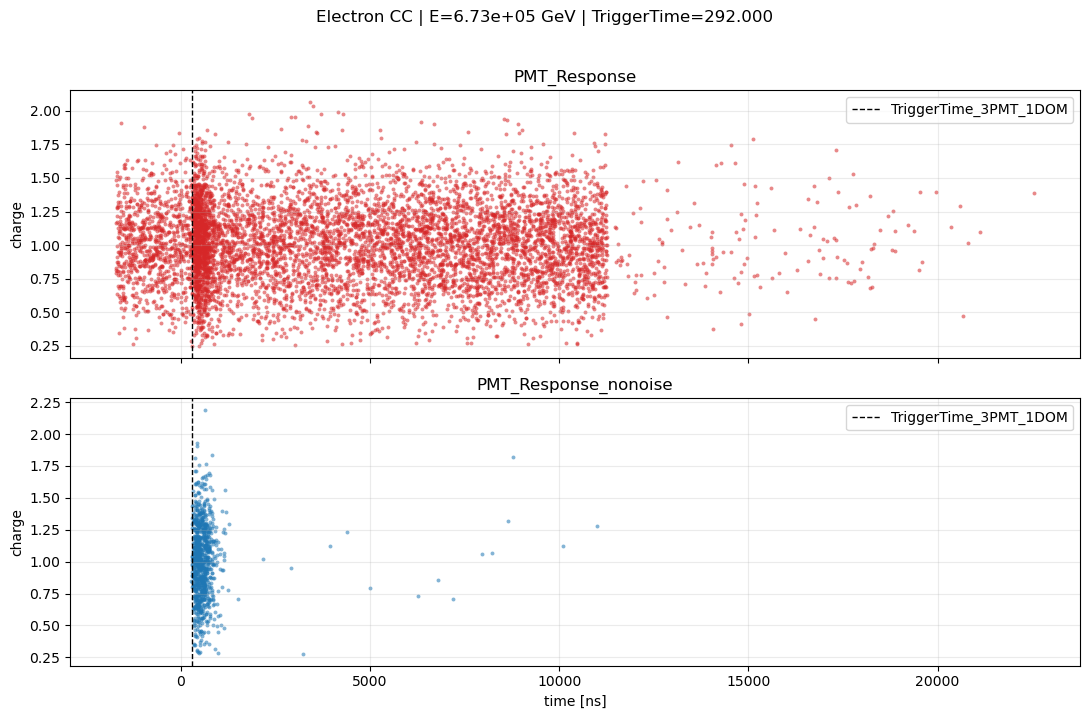

Electron CC | E=153 GeV
/scratch/kbas/String340MC/Full_Geometry/Electron_PMT_Response/electron_gen_000.i3.gz


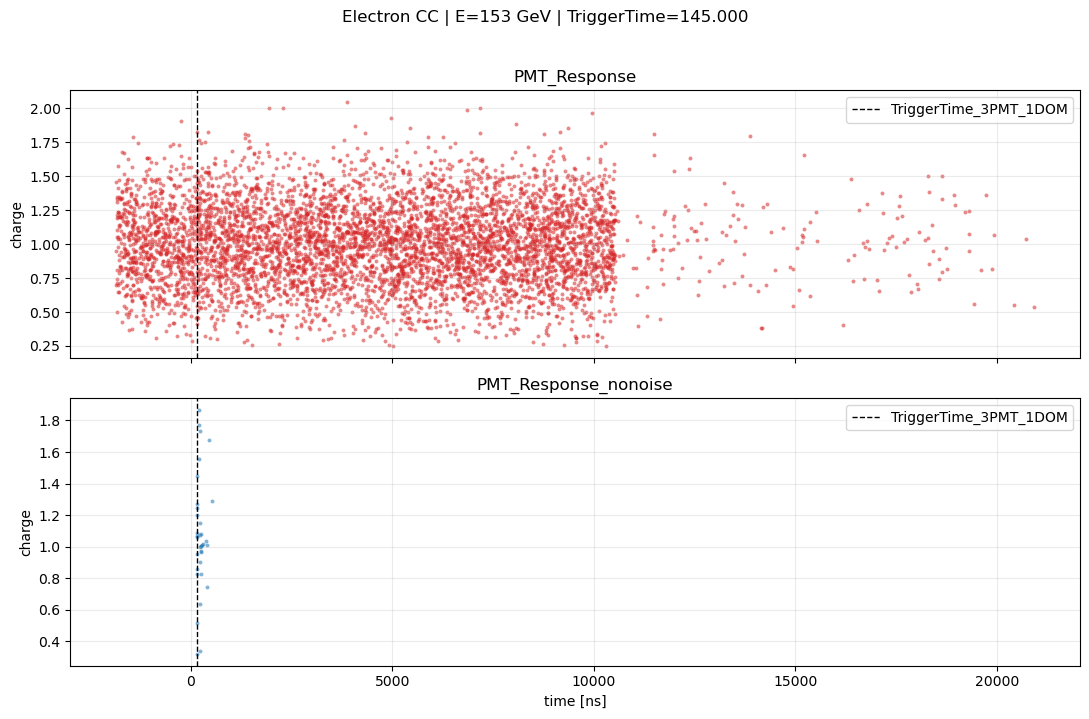

Muon CC | E=1.12e+05 GeV
/scratch/kbas/String340MC/Full_Geometry/Muon_PMT_Response/muon_cls_000.i3.gz


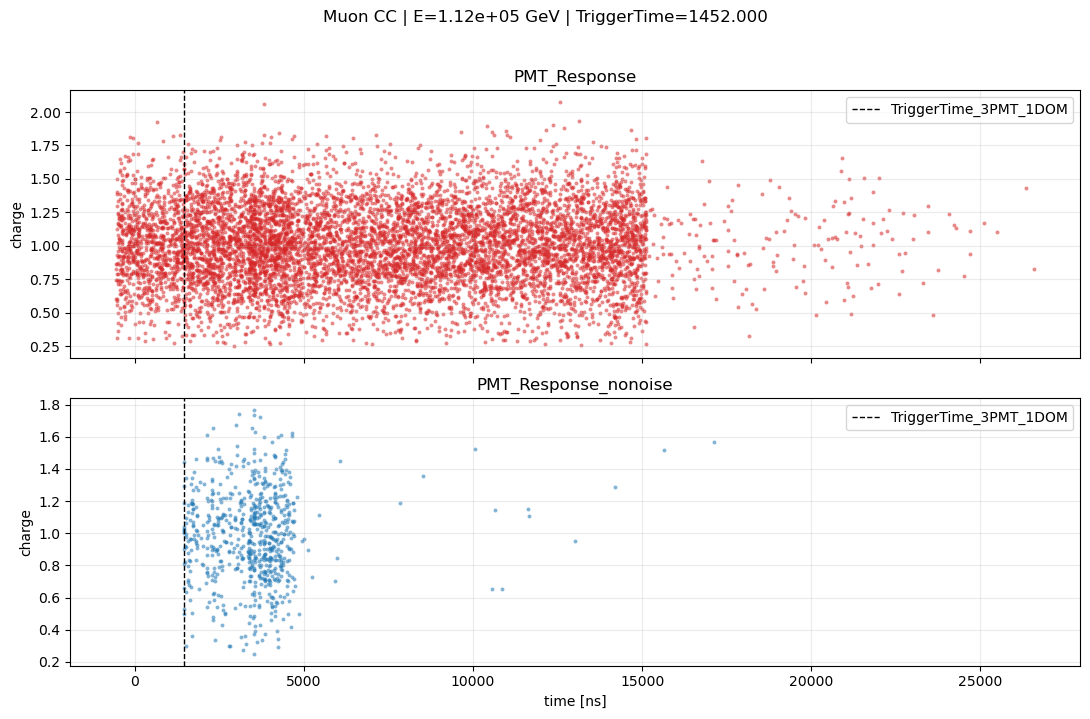

Muon CC | E=119 GeV
/scratch/kbas/String340MC/Full_Geometry/Muon_PMT_Response/muon_cls_000.i3.gz


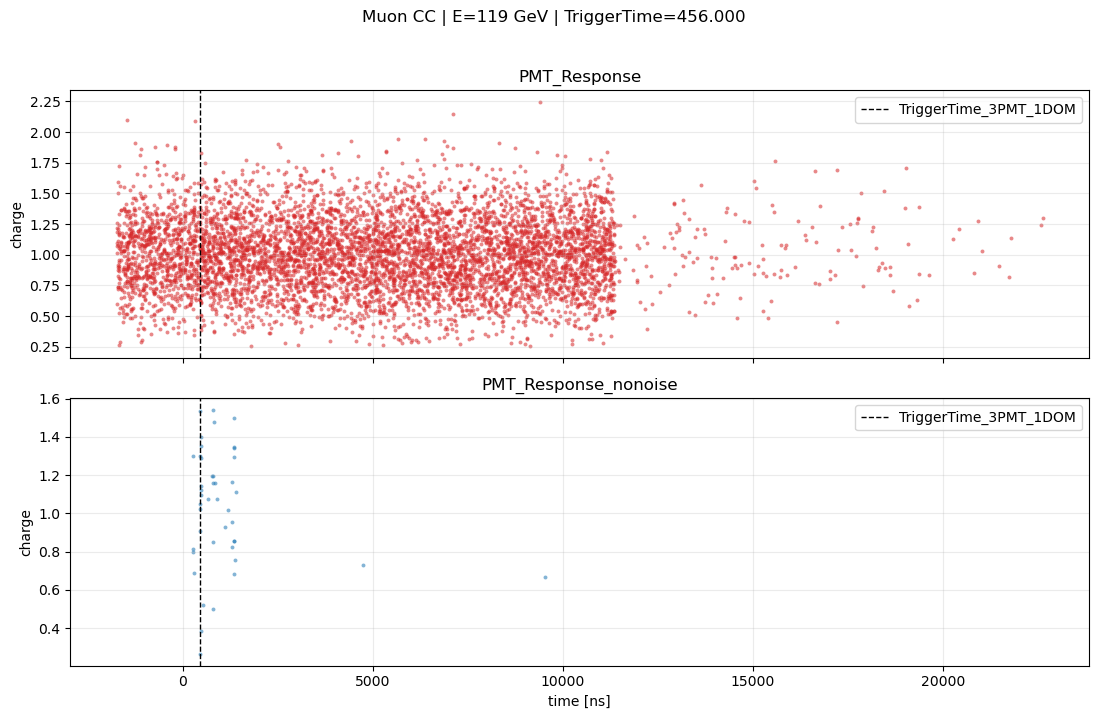

NC Interaction | E=1.04e+05 GeV
/scratch/kbas/String340MC/Full_Geometry/NC_PMT_Response/nc_gen_000.i3.gz


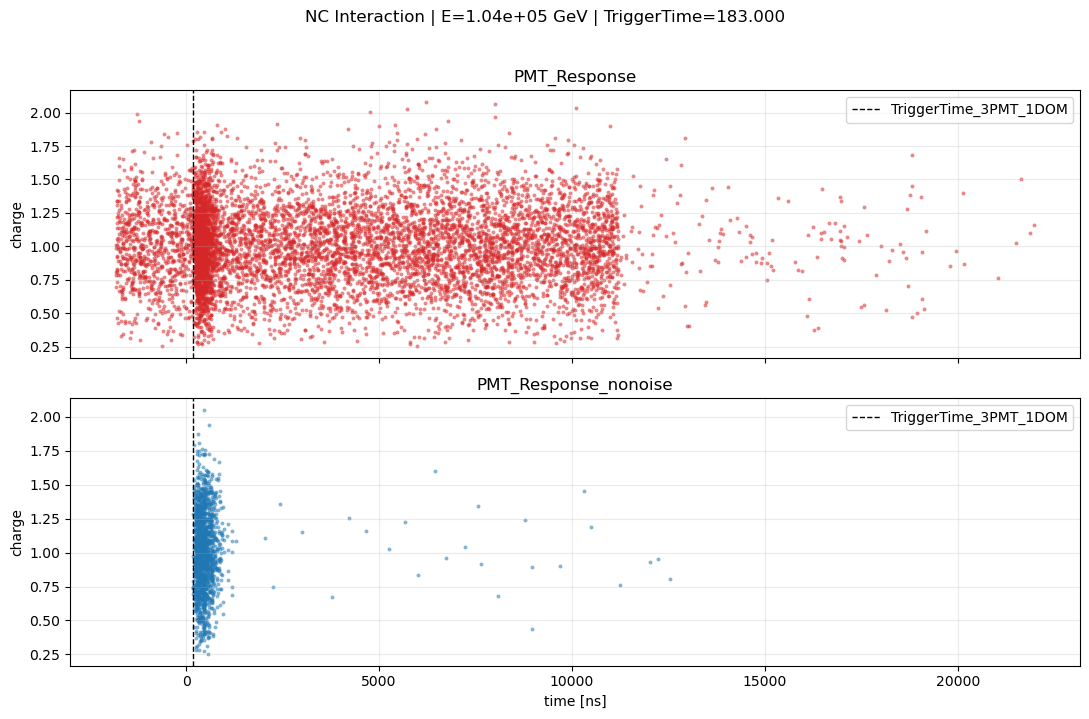

NC Interaction | E=105 GeV
/scratch/kbas/String340MC/Full_Geometry/NC_PMT_Response/nc_gen_000.i3.gz


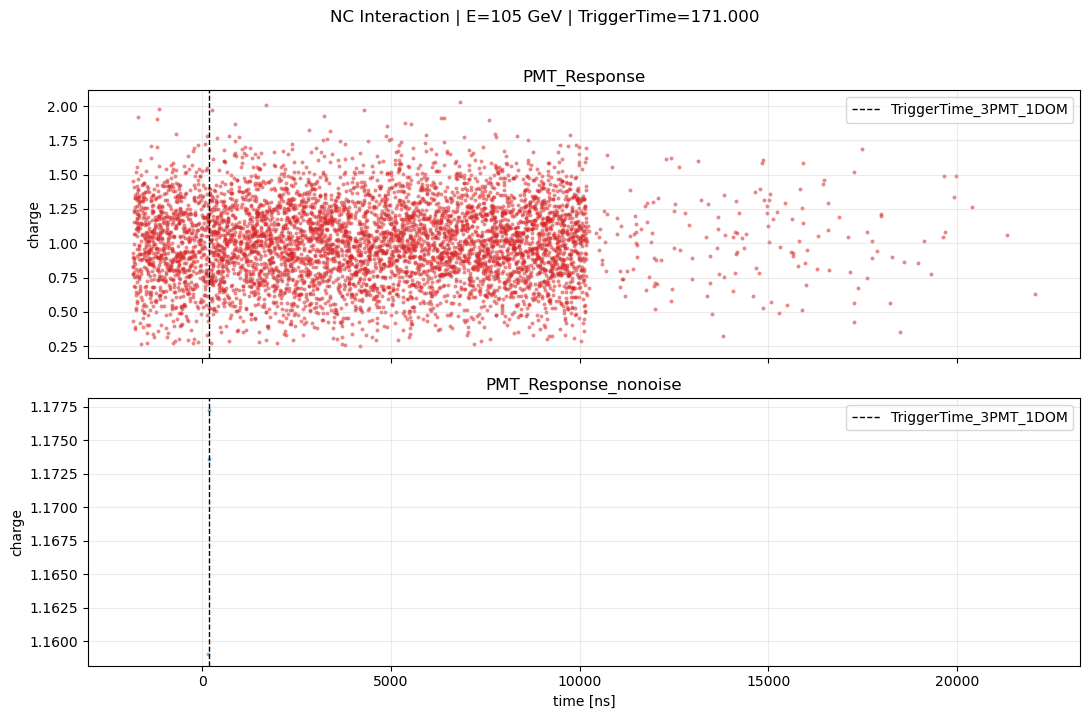

Tau CC | E=1.34e+05 GeV
/scratch/kbas/String340MC/Full_Geometry/Tau_PMT_Response/tau_gen_000.i3.gz


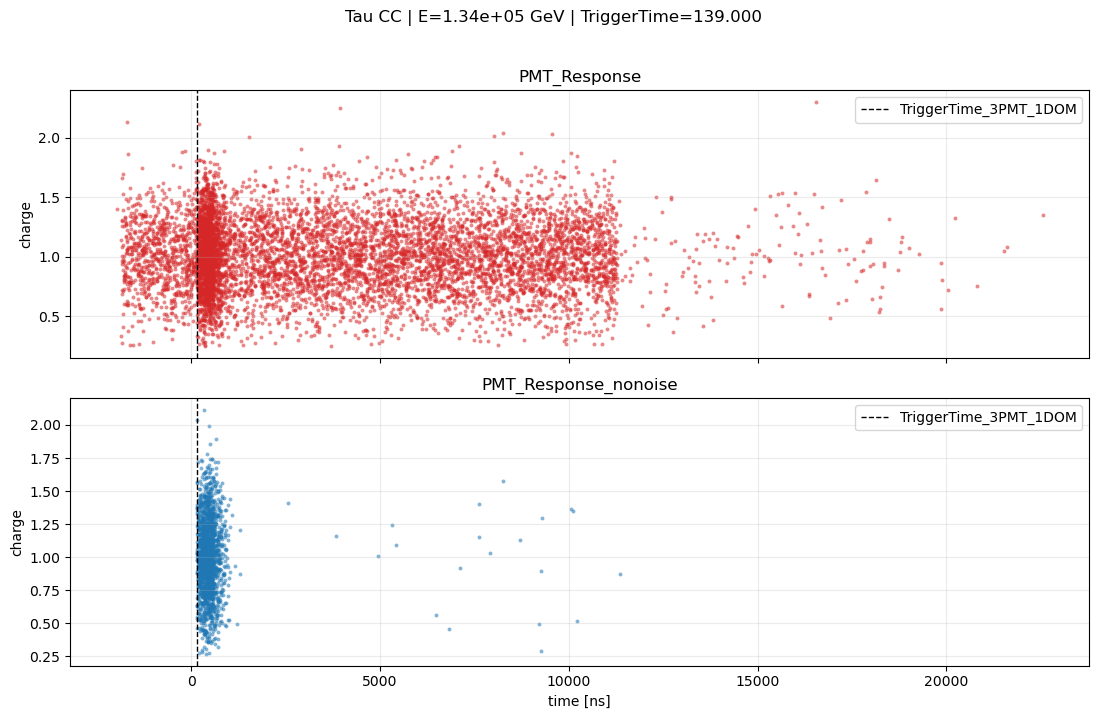

Tau CC | E=111 GeV
/scratch/kbas/String340MC/Full_Geometry/Tau_PMT_Response/tau_gen_000.i3.gz


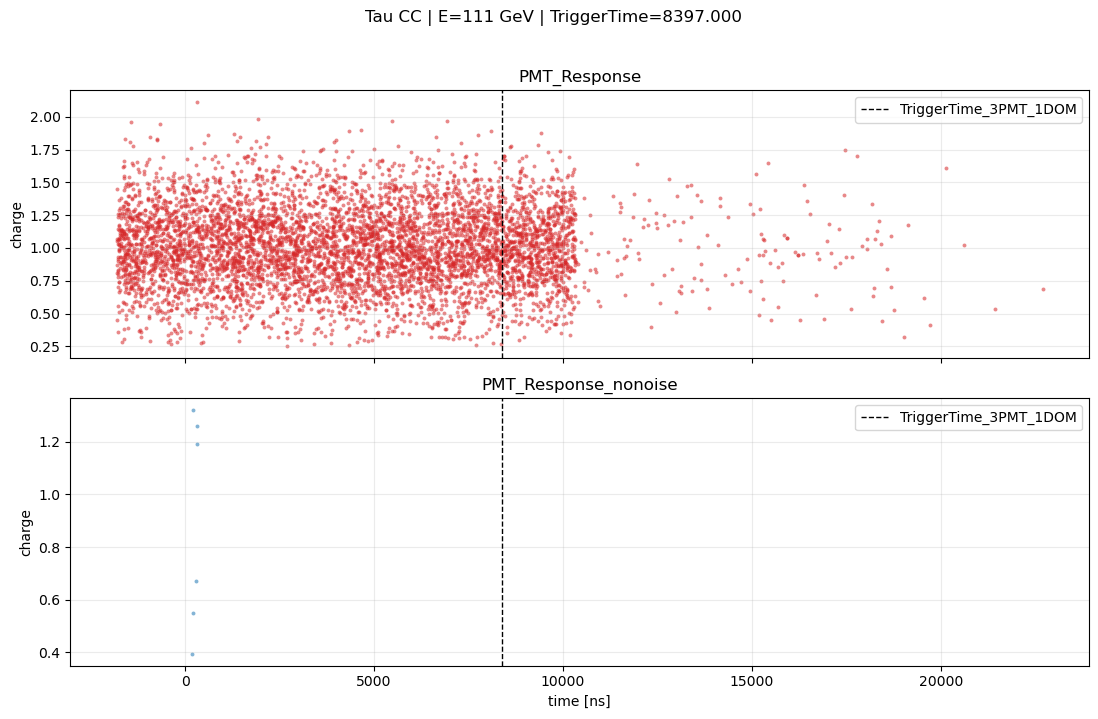

In [9]:
for _, row in selected_df.sort_values(["flavor", "energy_bucket"]).iterrows():
    print("=" * 100)
    print(title_for_event(row))
    print(row["file"])
    frame = load_frame_by_index(row["file"], int(row["frame_index"]))
    plot_pmt_response_vs_nonoise(frame, row)


## 102 String Subselection


Electron CC | E=1.63e+04 GeV
/scratch/kbas/String340MC/102_string/Electron_PMT_Response/electron_electron_gen_001.i3.gz


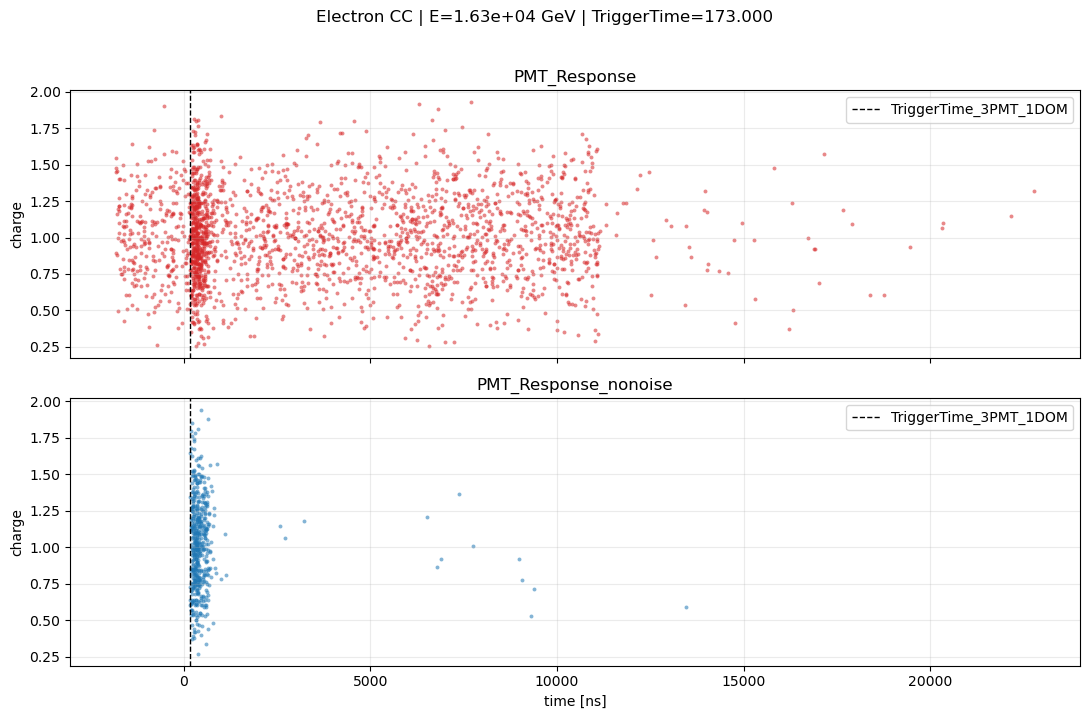

Electron CC | E=686 GeV
/scratch/kbas/String340MC/102_string/Electron_PMT_Response/electron_electron_gen_000.i3.gz


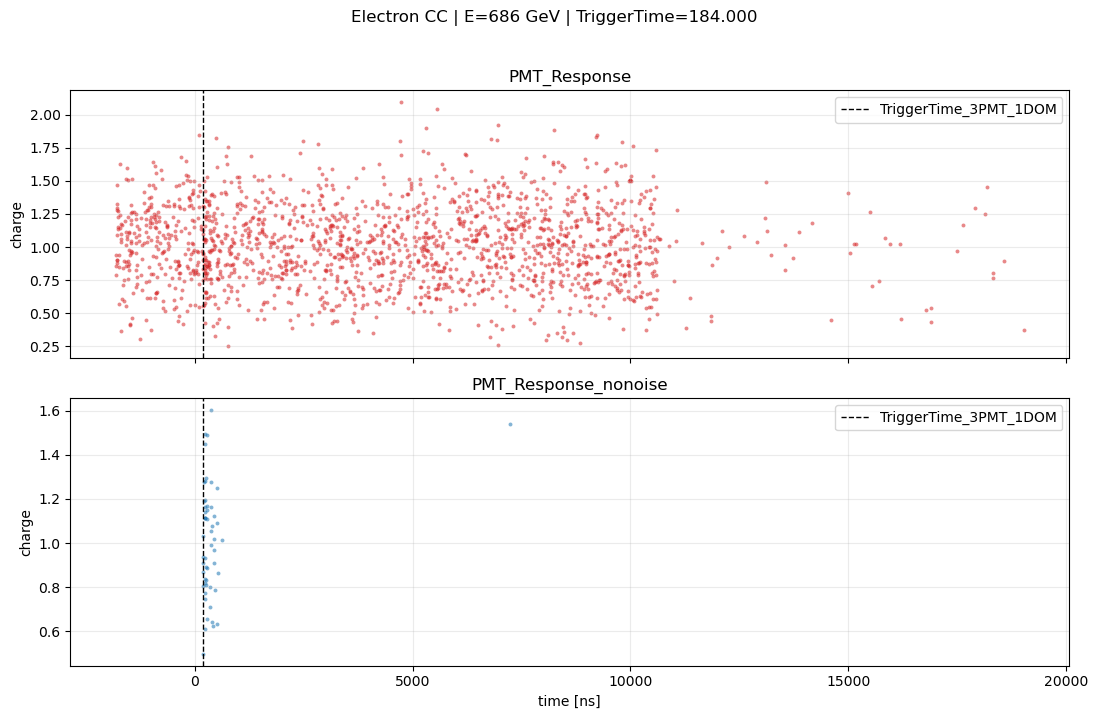

Muon CC | E=1.12e+05 GeV
/scratch/kbas/String340MC/102_string/Muon_PMT_Response/muon_muon_cls_000.i3.gz


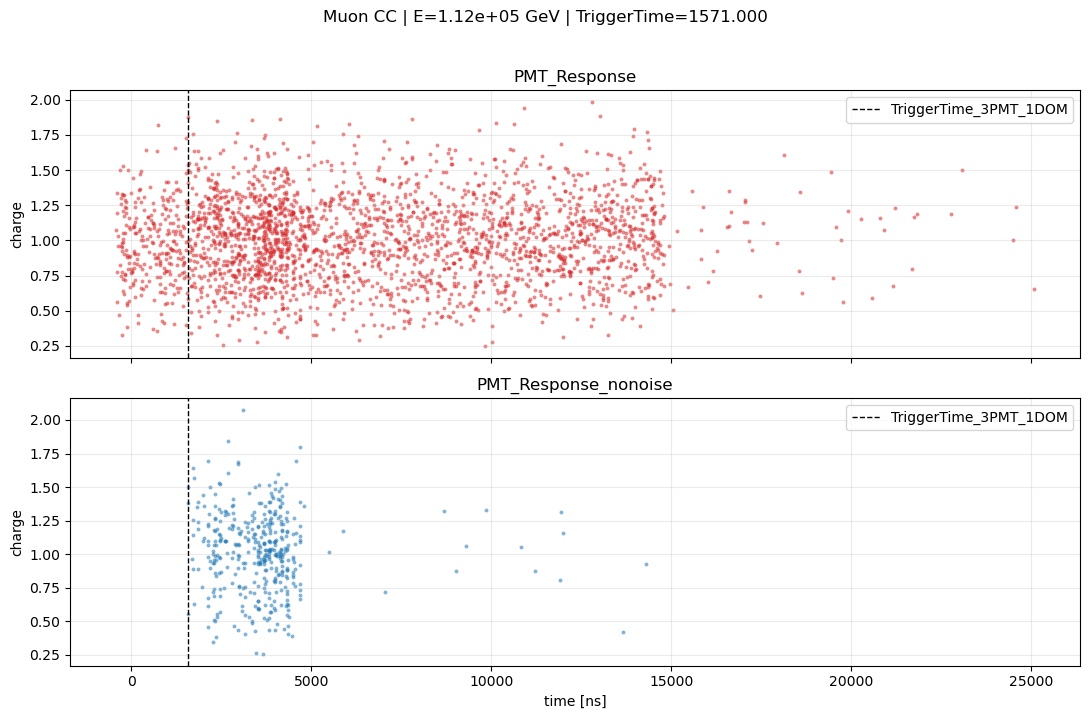

Muon CC | E=119 GeV
/scratch/kbas/String340MC/102_string/Muon_PMT_Response/muon_muon_cls_000.i3.gz


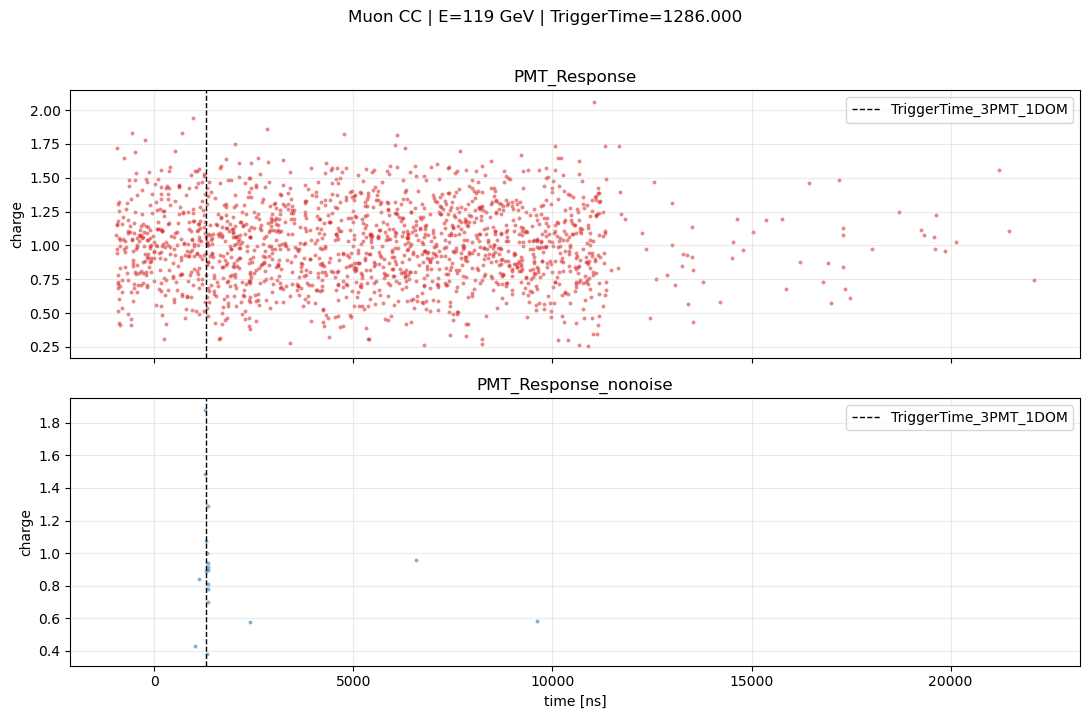

NC Interaction | E=1.04e+05 GeV
/scratch/kbas/String340MC/102_string/NC_PMT_Response/nc_nc_gen_000.i3.gz


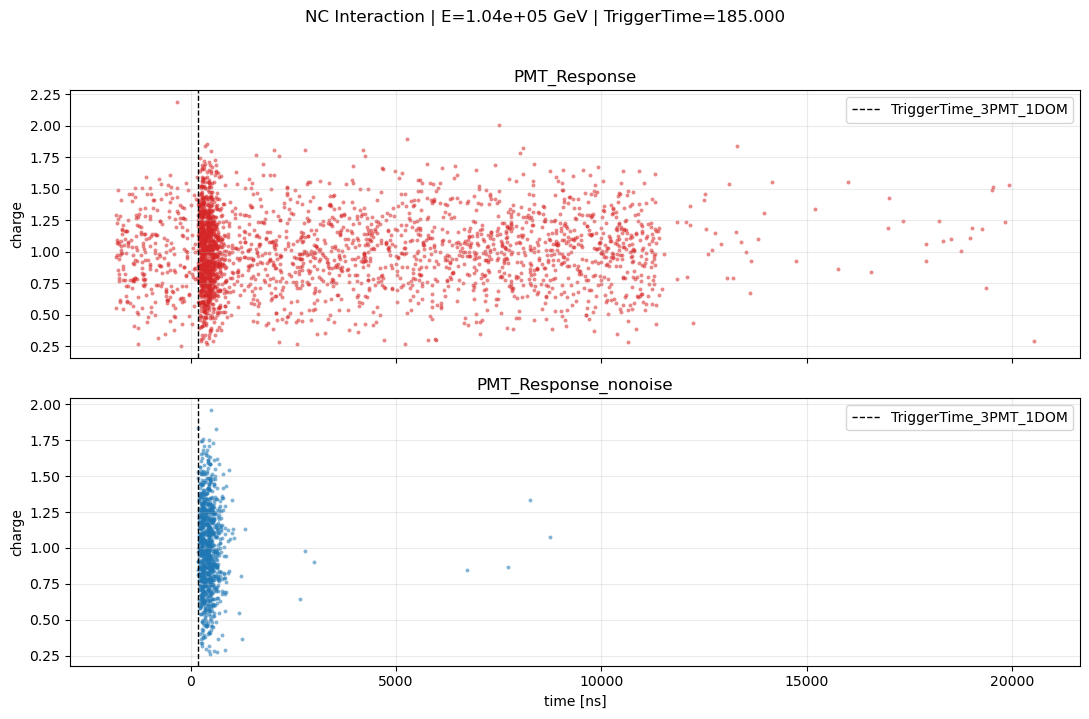

NC Interaction | E=630 GeV
/scratch/kbas/String340MC/102_string/NC_PMT_Response/nc_nc_gen_000.i3.gz


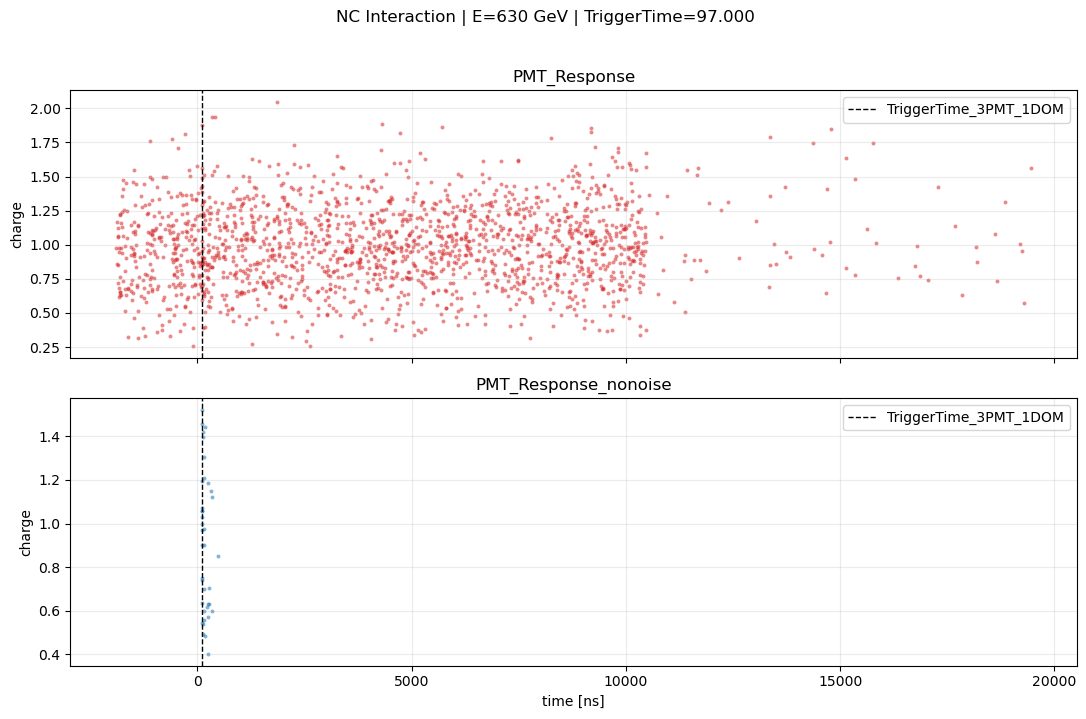

Tau CC | E=3.91e+04 GeV
/scratch/kbas/String340MC/102_string/Tau_PMT_Response/tau_tau_gen_007.i3.gz


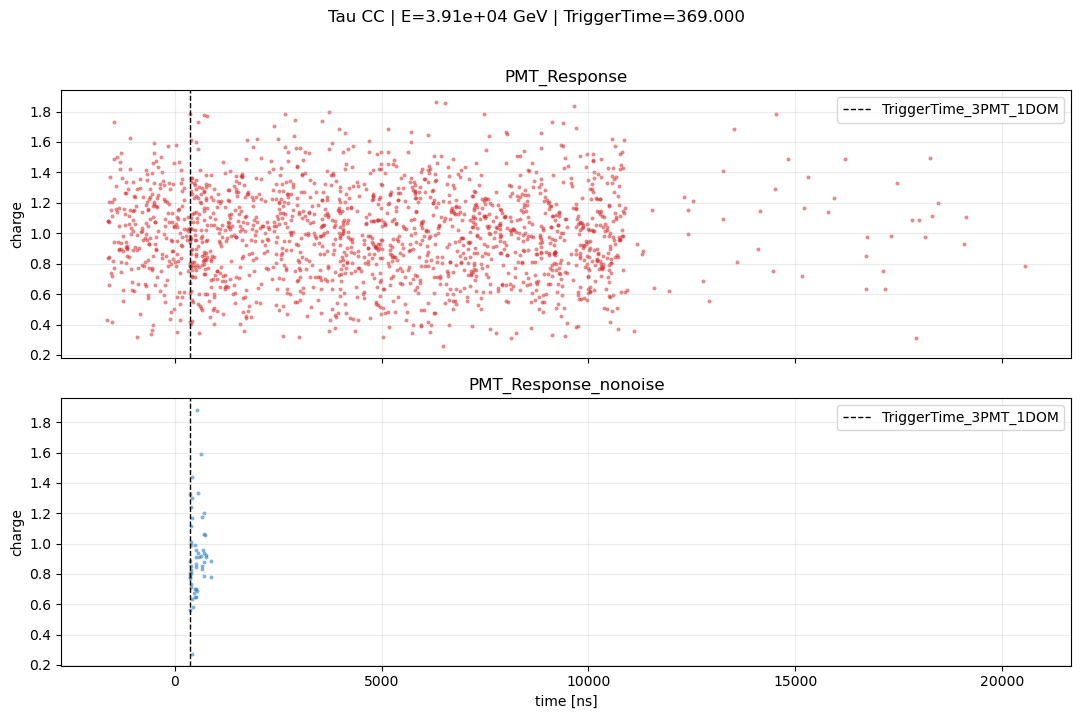

Tau CC | E=346 GeV
/scratch/kbas/String340MC/102_string/Tau_PMT_Response/tau_tau_gen_001.i3.gz


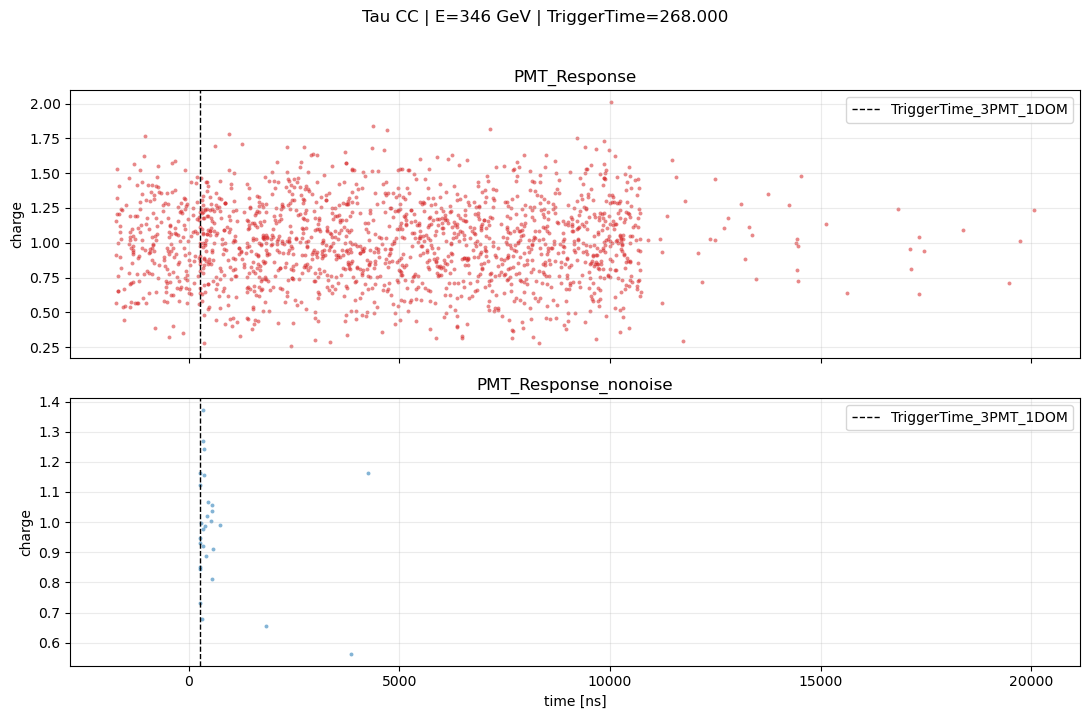

In [10]:
for _, row in selected_102_df.sort_values(["flavor", "energy_bucket"]).iterrows():
    print("=" * 100)
    print(title_for_event(row))
    print(row["file"])
    frame = load_frame_by_index(row["file"], int(row["frame_index"]))
    plot_pmt_response_vs_nonoise(frame, row)
